# Finding Stable Regime from Spinup to Sparse

This notebook is meant to test whether we are entering a stable regime or not in each LES dataset. We will be specifically loking at how to determine what the average cloud cover is and how to determine when the Sparse phase begins looking at different values of cloud depth.  

In [ ]:
import numpy as np
import scipy
import pickle
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from scipy.ndimage import gaussian_filter1d as gf1d
import datetime
import PlotClouds as plot_clouds
import pp_model.PPmodel as pr
from scipy import signal

plt.rcParams['figure.figsize'] = [20,10]
plt.rcParams['figure.dpi'] = 50
plt.rcParams['savefig.dpi'] = 240

plt.rcParams['font.size'] = 30
plt.rcParams['legend.fontsize'] = 'large'
# Set tile width you want to use
tile_width = 8

In [ ]:
#set file number
fold_num = 4
file_num = 24
file_num_str = str(file_num).zfill(2)

# Import Tile width data set
nc_H = Dataset(('LES/%d/Precip/EMUSCU_snd_0' +
                                         file_num_str + '/EMUSCU_snd_0' + file_num_str + '_tw8.nc') %fold_num)
#make sure units are in meters
fac = 1000
# Import dimensions
nt,nx,ny = nc_H.variables['Tile Width %s'%(tile_width)].shape
# Define H_all
Index = np.arange(0,nx,tile_width)
# Multiplying by 1000 to change km into meters (og *1 *)
H_all = fac*nc_H.variables['Tile Width %s'%(tile_width)][:,Index,Index]
# define the number of tiles horizontal tiles
nTiles = nx//tile_width 
print(nTiles)

30


# Spaghetti Plot

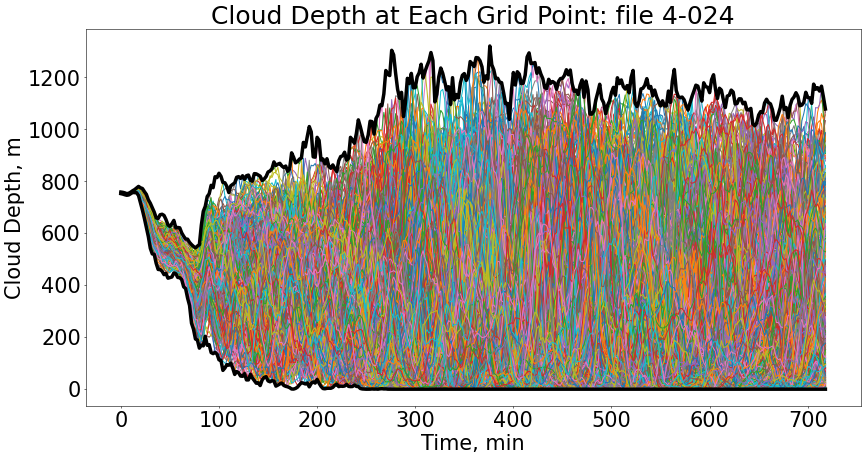

In [3]:
#plot signal
space_fac = int(720/len(H_all[:,0,0]))
xaxis = np.arange(0,720, space_fac)
plt.figure()
for kk in range(nTiles):
    for jj in range(nTiles):
        #find maximum
        plt.plot(xaxis, H_all[:,kk,jj]) #gf1d(H_all[:,kk,jj],5)) this is filtering the data
        #plt.show()
plot_max = 500
plt.plot(xaxis, np.amax(H_all, (1,2)), '-', color = 'k', linewidth = '5')
plt.plot(xaxis, np.amin(H_all, (1,2)), '-', color = 'k', linewidth = '5')
plt.title(('Cloud Depth at Each Grid Point: file %d-0' + file_num_str)%fold_num)
plt.xlabel('Time, min')
plt.ylabel('Cloud Depth, m')

plt.show()

# Determine Cloud Cover using Cloud Depth

In [4]:
cloud_cover = np.zeros(H_all.shape)
cc_threshold = 10
for kk in range(nTiles):
    for jj in range(nTiles):
        for ii in range(len(H_all[:,0,0])):
            if (H_all[ii,jj,kk] > cc_threshold): 
                cloud_cover[ii,jj,kk] = 1

cc_frac = np.sum(cloud_cover, axis = (1,2))/(nTiles*nTiles)


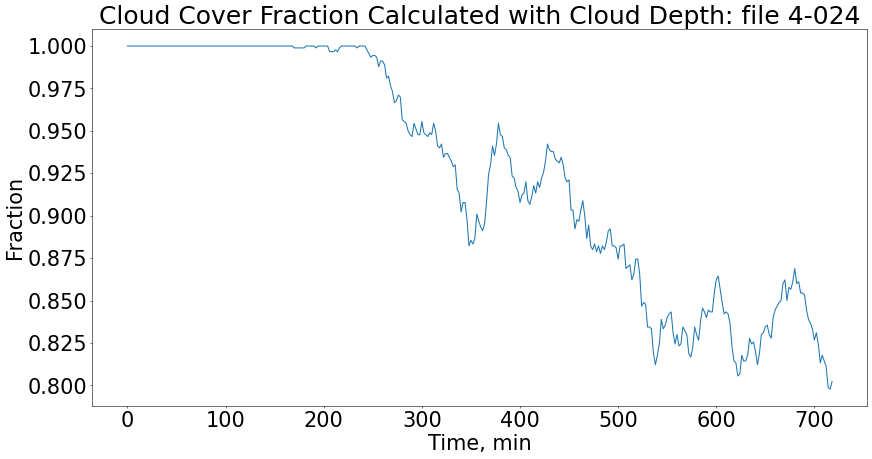

In [5]:
plt.figure()
plt.plot(xaxis,cc_frac)
plt.xlabel('Time, min')
plt.ylabel('Fraction')
plt.title(('Cloud Cover Fraction Calculated with Cloud Depth: file %d-0' + file_num_str)%fold_num)
plt.show()

# Testing cloud cover variable

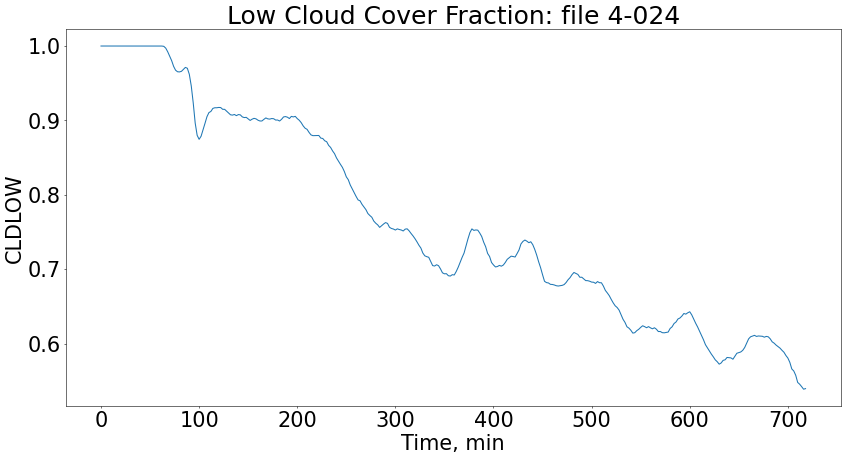

In [9]:
fold_num = 4
file_num = 24
file_num_str = str(file_num).zfill(2)
cc = Dataset(('files/%d/Precip/EMUSCU_snd_0'+ file_num_str +
             '/EMULATOR_SCU_240x240x250_dx200_dz10_dt1s_12h.nc') %fold_num)
t  = cc.variables['time'][:]
CLDLOW = cc.variables['CLDLOW'][:]
plt.figure()
plt.plot(xaxis[:],CLDLOW[:])
plt.xlabel('Time, min')
plt.ylabel('CLDLOW')
plt.title(('Low Cloud Cover Fraction: file %d-0' + file_num_str)%fold_num)
plt.show()

140
280


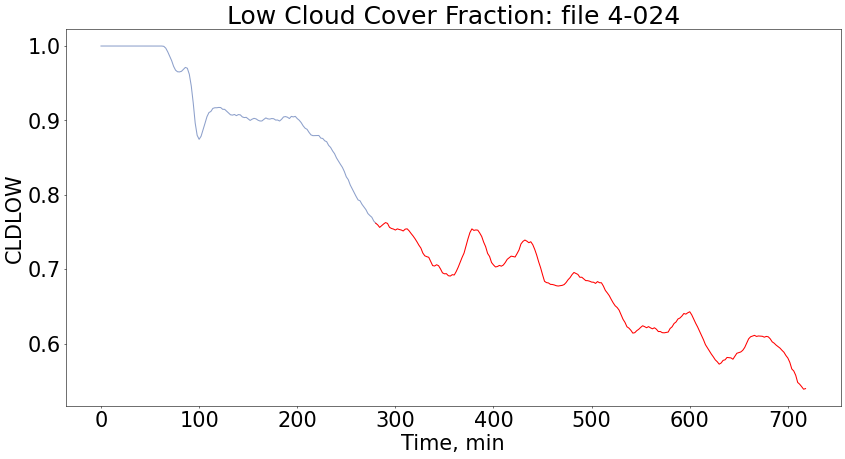

In [13]:
my_spinup = pr.find_spinup_end(CLDLOW) 
print(my_spinup)

print(xaxis[my_spinup])
plt.figure()
plt.plot(xaxis[:my_spinup + 1],CLDLOW[:my_spinup + 1], c = '#8da0cb')
plt.plot(xaxis[my_spinup:],CLDLOW[my_spinup:], c = 'r')
plt.xlabel('Time, min')
plt.ylabel('CLDLOW')
plt.title(('Low Cloud Cover Fraction: file %d-0' + file_num_str)%fold_num)
plt.show()

# Testing All datasets for PREC varaible 

Only run this when file paths are all in the same folder
Once they are sorted, file paths are different and will no longer work accordingly 

In [ ]:
file_folder = 1
total_files = 58
under_3_array = np.empty(total_files)
for i in range(1, total_files+1):
    if (i < 10): 
        data_str = str(('LES/%d/EMUSCU_snd_00%d/EMULATOR_SCU_240x240x250_dx200_dz10_dt1s_12h.nc')%(file_folder,i))
    else: 
        data_str = str(('LES/%d/EMUSCU_snd_0%d/EMULATOR_SCU_240x240x250_dx200_dz10_dt1s_12h.nc') %(file_folder,i))
    nc = Dataset(data_str)
    PREC = nc.variables['PREC'][:]
    under_3_array[i - 1] = all(kk < 1.0e-3 for kk in PREC)


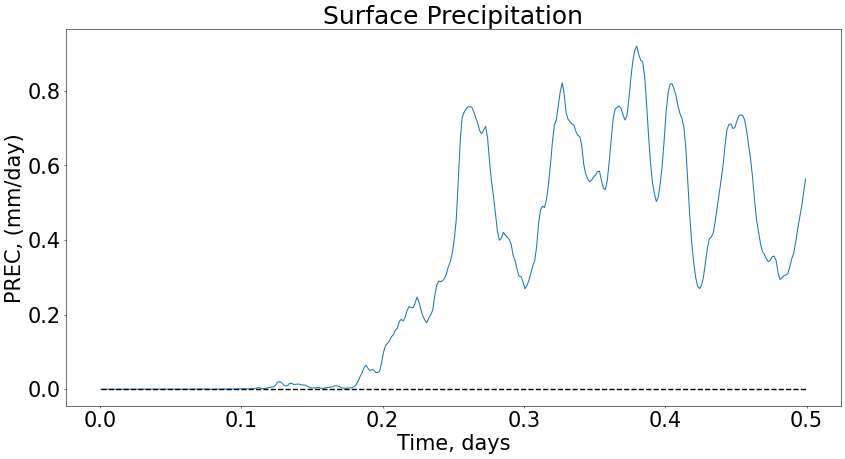

In [ ]:
nc = Dataset('LES/4/Precip/EMUSCU_snd_024/EMULATOR_SCU_240x240x250_dx200_dz10_dt1s_12h.nc')
t  = nc.variables['time'][:]
PREC = nc.variables['PREC'][:]
plt.figure()
plt.plot(t,PREC)
plt.plot(t, 1.0e-3*np.ones(len(t)), '--', color = 'k', linewidth = 2)
plt.xlabel('Time, days')
plt.ylabel('PREC, (mm/day)')
plt.title('Surface Precipitation')
plt.show()